In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  confusion_matrix, accuracy_score

### Работа с датасетом

In [21]:
df = pd.read_csv('train.csv')
df.head(5)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


##### Признаки: 
###### battery_power - емкость батареи в mAh (100-2000 mAh), 
###### blue - наличие Bluetooth (0 - нет, 1 - есть),
###### clock_speed - тактовая частота процессора (0.5-3.0 GHz),
###### dual_sim - поддержка двух SIM-карт (0 - нет, 1 - есть),
###### fc - разрешение фронтальной камеры в мегапикселях (0-19 MP), 
###### four_g - поддержка 4G (0 - нет, 1 - есть), 
###### int_memory - объем внутренней памяти (2-64 GB),
###### m_dep - толщина телефона  (0.1-1.0 cm), 
###### mobile_wt - вес телефона (80-200g),
###### n_cores - количество ядер процессора (1-8 cores),
###### pc - разрешение основной камеры в мегапикселях (0-20 MP),
###### px_height - высота экрана в пикселях (0-1960 px), 
###### px_width - ширина экрана в пикселях (500-1998 px), 
###### ram - объем оперативной памяти (256-3998 MB),
###### sc_h - высота экрана в см (5-19 cm), 
###### sc_w - ширина экрана в см (0-18 cm),
###### talk_time - время разговора (2-20 hours), 
###### three_g - поддержка 3G (0 - нет, 1 - есть), 
###### touch_screen - сенсорный экран (0 - нет, 1 - есть),
###### wifi - поддержка Wi-Fi (0 - нет, 1 - есть)

##### Целевая переменная:
###### price_range - ценовой диапазон телефона (0-3)  : 0 - низкая цена ,1 - средняя цена, 2 - высокая цена, 3 - премиальная цена

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

##### нет пропусков, все признаки числовые, бинарные признаки закодированы 0/1, целевая переменная в правильном формате

##### EDA

##### распределение ключевых признаков по ценовым категориям


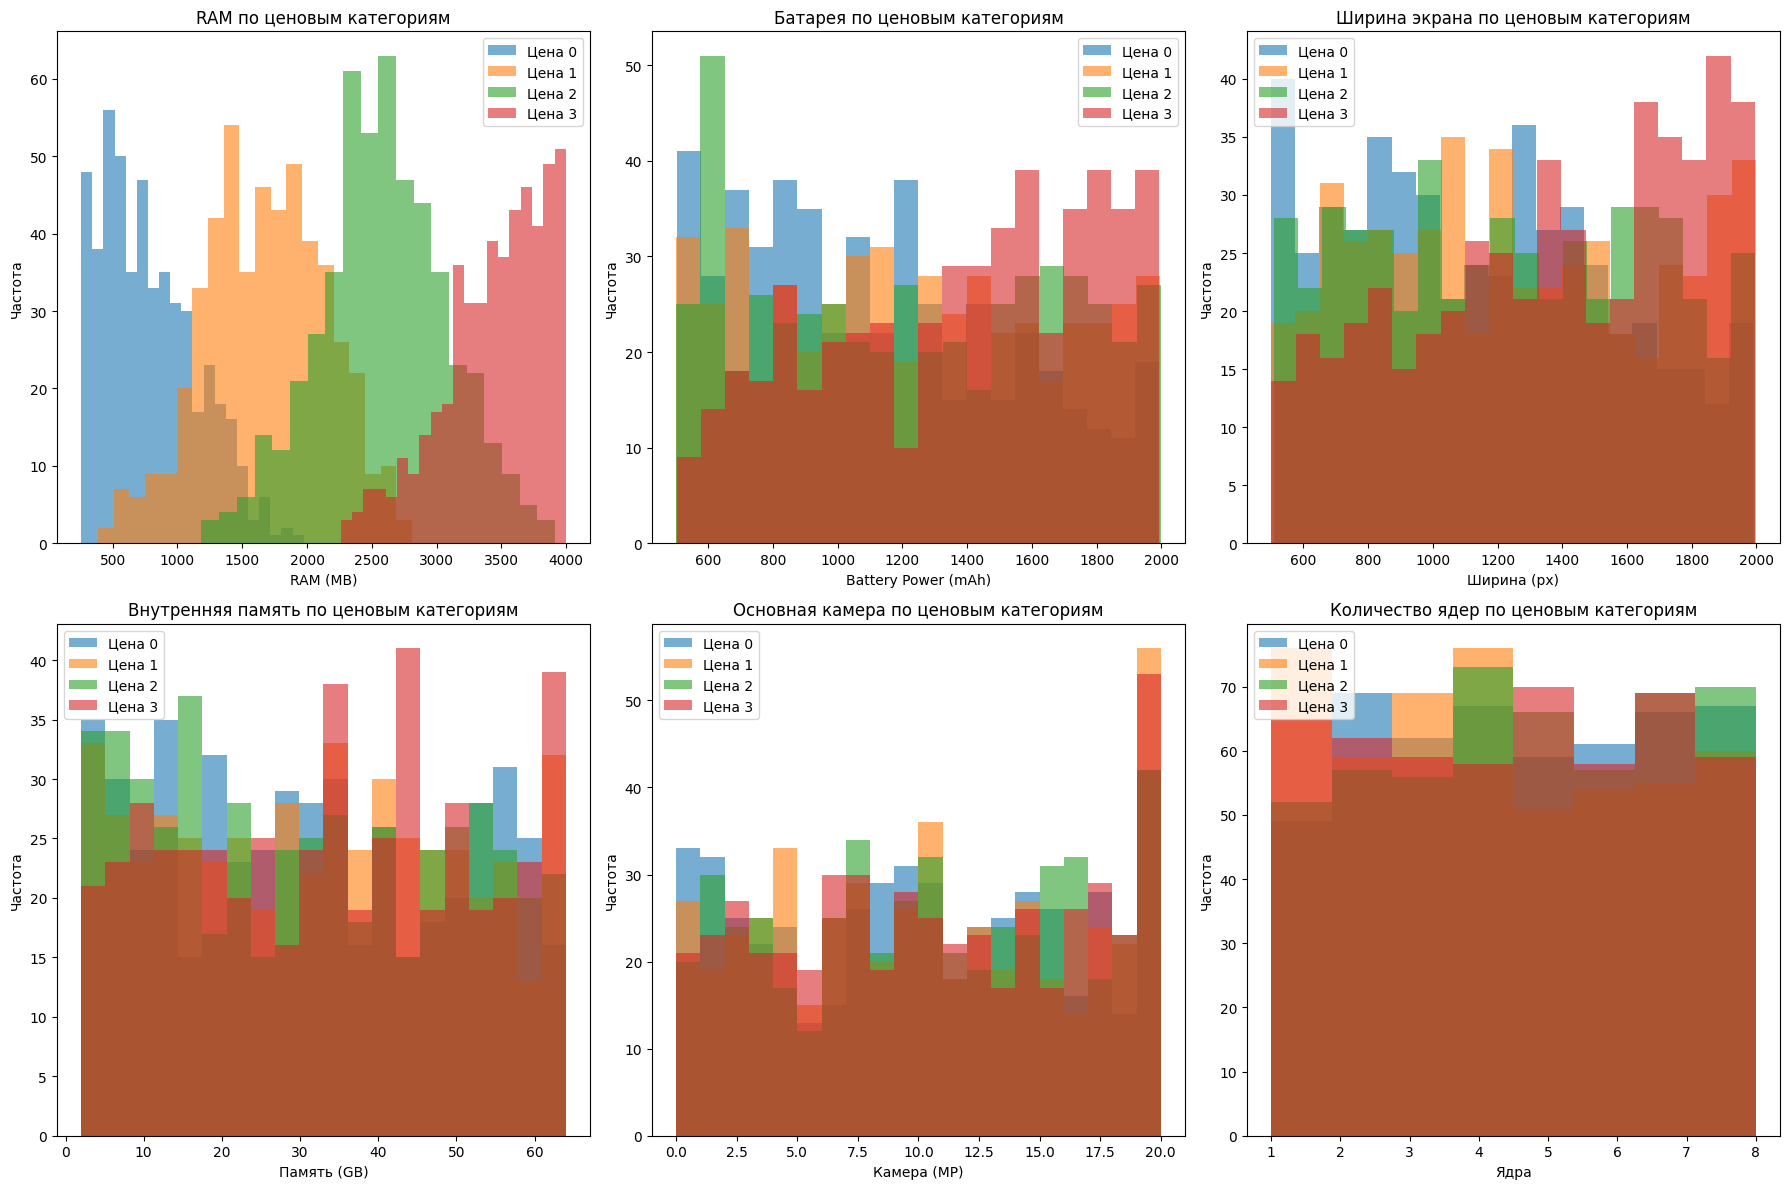

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ax = axes[0, 0]
for price_range in sorted(df['price_range'].unique()):
    subset = df[df['price_range'] == price_range]
    ax.hist(subset['ram'], bins=20, alpha=0.6, label=f'Цена {price_range}')
ax.set_title('RAM по ценовым категориям')
ax.set_xlabel('RAM (MB)')
ax.set_ylabel('Частота')
ax.legend()

ax = axes[0, 1]
for price_range in sorted(df['price_range'].unique()):
    subset = df[df['price_range'] == price_range]
    ax.hist(subset['battery_power'], bins=20, alpha=0.6, label=f'Цена {price_range}')
ax.set_title('Батарея по ценовым категориям')
ax.set_xlabel('Battery Power (mAh)')
ax.set_ylabel('Частота')
ax.legend()

ax = axes[0, 2]
for price_range in sorted(df['price_range'].unique()):
    subset = df[df['price_range'] == price_range]
    ax.hist(subset['px_width'], bins=20, alpha=0.6, label=f'Цена {price_range}')
ax.set_title('Ширина экрана по ценовым категориям')
ax.set_xlabel('Ширина (px)')
ax.set_ylabel('Частота')
ax.legend()

ax = axes[1, 0]
for price_range in sorted(df['price_range'].unique()):
    subset = df[df['price_range'] == price_range]
    ax.hist(subset['int_memory'], bins=20, alpha=0.6, label=f'Цена {price_range}')
ax.set_title('Внутренняя память по ценовым категориям')
ax.set_xlabel('Память (GB)')
ax.set_ylabel('Частота')
ax.legend()

ax = axes[1, 1]
for price_range in sorted(df['price_range'].unique()):
    subset = df[df['price_range'] == price_range]
    ax.hist(subset['pc'], bins=20, alpha=0.6, label=f'Цена {price_range}')
ax.set_title('Основная камера по ценовым категориям')
ax.set_xlabel('Камера (MP)')
ax.set_ylabel('Частота')
ax.legend()

ax = axes[1, 2]
for price_range in sorted(df['price_range'].unique()):
    subset = df[df['price_range'] == price_range]
    ax.hist(subset['n_cores'], bins=8, alpha=0.6, label=f'Цена {price_range}')
ax.set_title('Количество ядер по ценовым категориям')
ax.set_xlabel('Ядра')
ax.set_ylabel('Частота')
ax.legend()

plt.tight_layout()
plt.show()

##### Ключевые закономерности по ценовым категориям:
##### RAM:
###### Бюджетные (0): в основном до 1000 MB
###### Средние (1) примерно 1000-2000 MB
###### Дорогие (2) примерно 2000-3000 MB
###### Премиум (3)примерно 3000-4000 MB
##### Вывод: RAM - четкий индикатор цены
##### Батарея: более дорогие телефоны имеют большую батарею
##### Экран: Ширина экрана увеличивается с ценой

##### Бинарные признаки 

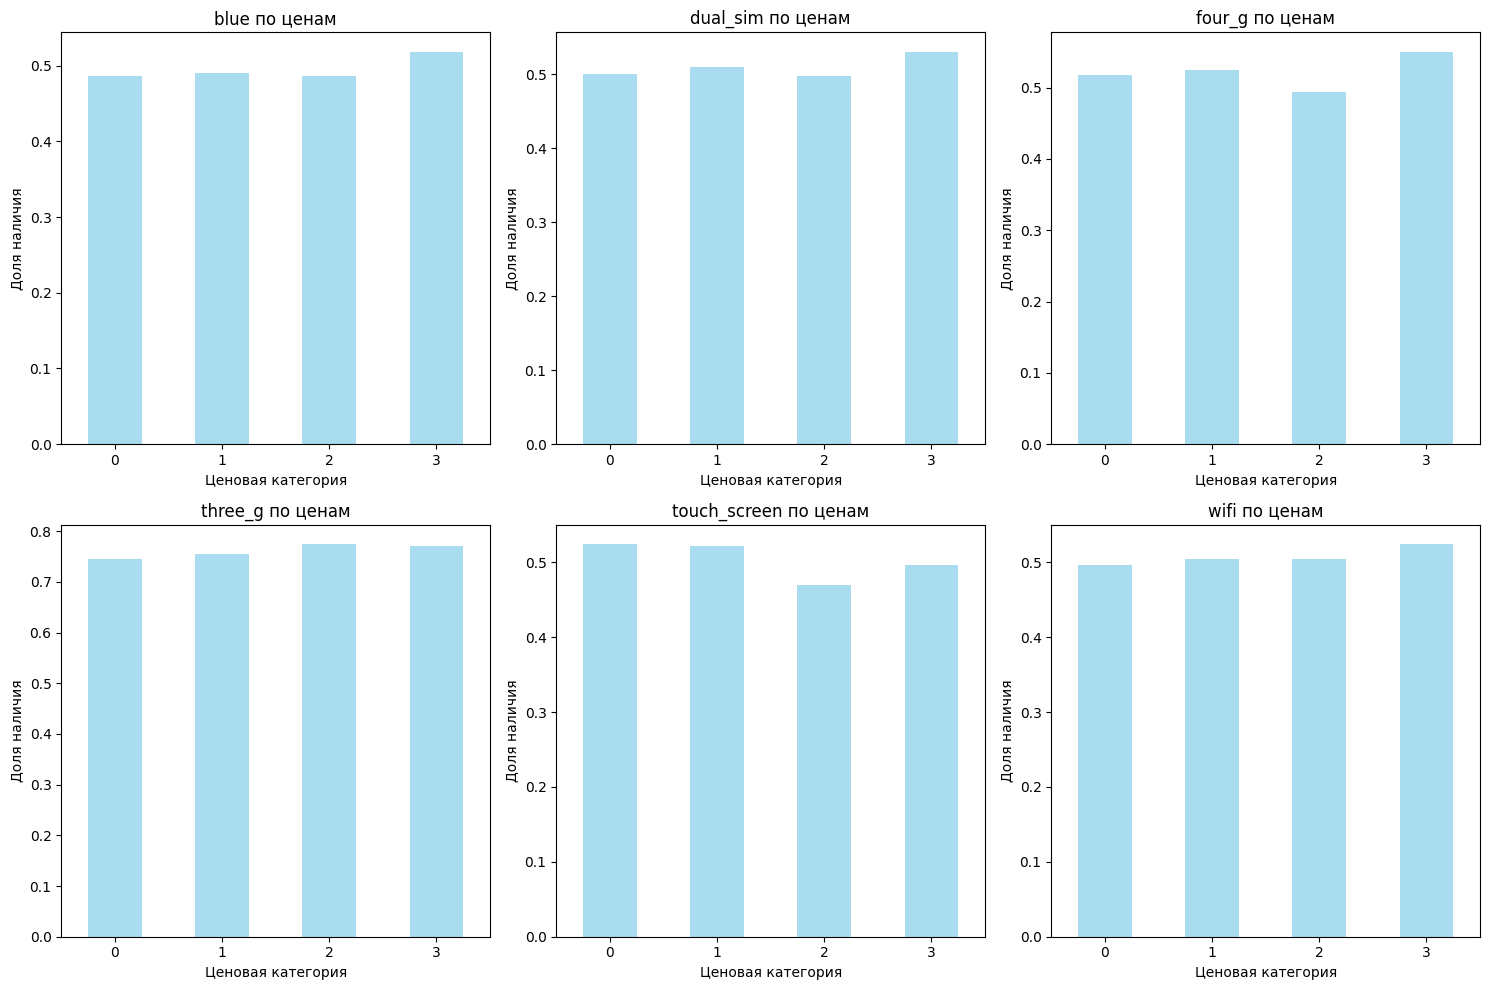

In [24]:
binary_features = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(binary_features, 1):
    plt.subplot(2, 3, i)
    df.groupby('price_range')[feature].mean().plot(kind='bar', color='skyblue', alpha=0.7)
    plt.title(f'{feature} по ценам')
    plt.xlabel('Ценовая категория')
    plt.ylabel('Доля наличия')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##### вывод:  бинарные признаки практически не влияют на ценовой диапазон, т.к. стали стандартной функциональностью для всех категорий телефонов

##### Корреляция с целевой переменной

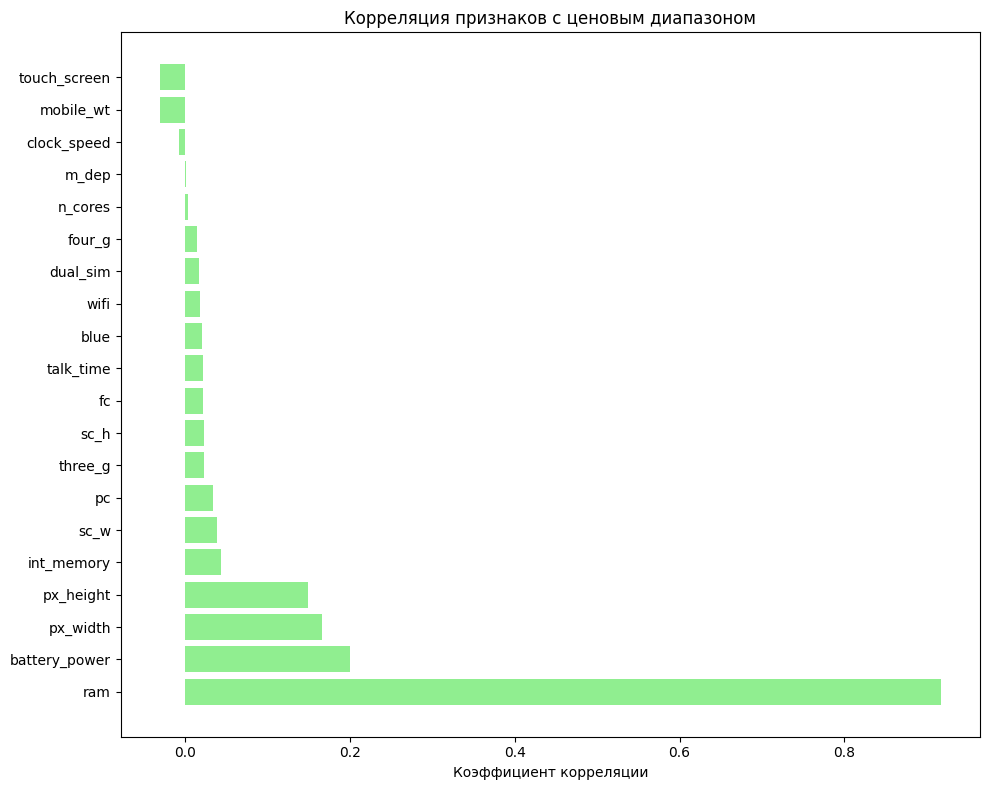

In [25]:
plt.figure(figsize=(10, 8))
corr_with_target = df.corr()['price_range'].sort_values(ascending=False)
corr_with_target.drop('price_range', inplace=True)
plt.barh(corr_with_target.index, corr_with_target.values, color='lightgreen')
plt.title('Корреляция признаков с ценовым диапазоном')
plt.xlabel('Коэффициент корреляции')
plt.tight_layout()
plt.show()

##### Самые важные признаки для классификации:
###### RAM (корреляция примерно 0.9) - самый сильный предиктор
###### Battery Power (примерно0.2)
###### Разрешение экрана (px_width примерно 0.17, px_height примерно 0.15)
###### Внутренняя память (примерно 0.13)

##### удаление маловажных признаков

In [40]:
corr_with_target = df.corr()['price_range'].abs().sort_values(ascending=True)

low_correlation_threshold = 0.02
features_to_drop = []

for feature, corr in corr_with_target.items():
    if feature != 'price_range' and corr < low_correlation_threshold:
        features_to_drop.append(feature)

for feature in features_to_drop:
    actual_corr = df.corr()['price_range'][feature]
    print(f"{feature:20} : {actual_corr:.4f}")

df = df.drop(columns=features_to_drop)

##### все признаки с корреляцией > 0.02 остались
##### размер датасета после удаления: (2000, 15)
###### оставшиеся признаки: ['battery_power', 'blue', 'fc', 'int_memory', 'mobile_wt', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'price_range']

##### создаем новые (Feature Engineering)

In [27]:
df['pixel_density'] = df['px_height'] * df['px_width']

df['total_camera_mp'] = df['pc'] + df['fc']

df['battery_efficiency'] = df['battery_power'] / (df['mobile_wt'] + 1)

df['power_score'] = (df['ram'] * 0.6 + 
                     df['battery_power'] * 0.3 + 
                     df['int_memory'] * 0.1)

df['screen_area_cm2'] = df['sc_h'] * df['sc_w']

##### новые признаки:
###### pixel_density - общее количество пикселей экрана,
###### total_camera_mp - суммарное качество камер
###### battery_efficiency - емкость батареи на единицу веса
###### power_score - композитный показатель мощности
###### screen_area_cm2 - площадь экрана в см^2 

##### проверка эффективности новых признаков

In [28]:
new_features = ['pixel_density',  'total_camera_mp', 
                'battery_efficiency', 'power_score', 'screen_area_cm2']

for feature in new_features:
    if feature in df.columns:
        corr = df[feature].corr(df['price_range'])
        importance = "высокая" if abs(corr) > 0.3 else "средняя" if abs(corr) > 0.1 else "низкая"
        print(f"{feature:20} : {corr:7.4f} - {importance}")

pixel_density        :  0.1762 - средняя
total_camera_mp      :  0.0316 - низкая
battery_efficiency   :  0.1775 - средняя
power_score          :  0.9388 - высокая
screen_area_cm2      :  0.0412 - низкая


##### Разделяем на признаки и целевую переменную

In [29]:
X = df.drop('price_range', axis=1)
y = df['price_range']

print(f"X: {X.shape}, y: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X: (2000, 19), y: (2000,)
Train: (1600, 19), Test: (400, 19)


##### RANDOM FOREST

In [30]:
rf_model = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)  

best_rf = rf_grid.best_estimator_
print(f"точность на кросс-валидации: {rf_grid.best_score_:.4f}")

y_pred_rf = best_rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Точность на тестовых данных: {rf_accuracy:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
точность на кросс-валидации: 0.9125
Точность на тестовых данных: 0.9550


##### Ошибок: 24 из 400 телефонов

##### K-NEAREST NEIGHBORS

In [31]:
knn_model = KNeighborsClassifier()

knn_params = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(knn_model, knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid.fit(X_train_scaled, y_train)  

best_knn = knn_grid.best_estimator_
print(f"точность на кросс-валидации: {knn_grid.best_score_:.4f}")

y_pred_knn = best_knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Точность на тестовых данных: {knn_accuracy:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
точность на кросс-валидации: 0.7312
Точность на тестовых данных: 0.7750


##### K-Nearest Neighbors показывает не лучшее качество для данной задачи. Модель значительно худе Random Forest   
##### ошибок: 96 из 400 телефонов - значительно больше других моделей

##### SVM 

In [32]:
svm_model = SVC(random_state=42)

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_

print(f"точность на кросс-валидации: {svm_grid.best_score_:.4f}")

y_pred_svm = best_svm.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Точность на тестовых данных: {svm_accuracy:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
точность на кросс-валидации: 0.9625
Точность на тестовых данных: 0.9750


##### ошибок:  10 из 400 телефонов

##### LOGISTIC REGRESSION

In [33]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

lr_grid = GridSearchCV(lr_model, lr_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_

print(f"точность на кросс-валидации: {lr_grid.best_score_:.4f}")

y_pred_lr = best_lr.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Точность на тестовых данных: {lr_accuracy:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
точность на кросс-валидации: 0.9631
Точность на тестовых данных: 0.9725


#####  ошибок: 11 из 400 телефонов, всего на 1 ошибку больше чем у SVM, качество почти такое же как и у SVM, но модель проще и быстрее

##### Сравнить все обученные модели, построить их confusion matrices

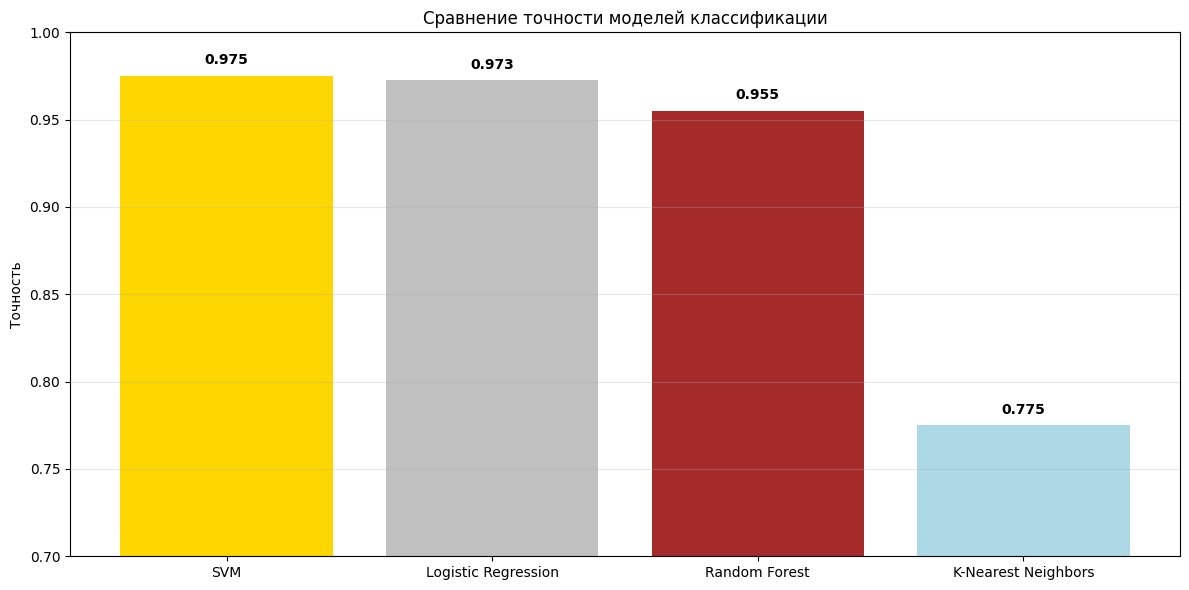

In [37]:
models = {
    'Random Forest': (y_pred_rf, rf_accuracy),
    'K-Nearest Neighbors': (y_pred_knn, knn_accuracy), 
    'SVM': (y_pred_svm, svm_accuracy),
    'Logistic Regression': (y_pred_lr, lr_accuracy)
}

results_comparison = pd.DataFrame({
    'Model': list(models.keys()),
    'Test Accuracy': [accuracy for _, accuracy in models.values()],
    'Best Parameters': [
        str(rf_grid.best_params_),
        str(knn_grid.best_params_), 
        str(svm_grid.best_params_),
        str(lr_grid.best_params_)
    ]
}).sort_values('Test Accuracy', ascending=False)

plt.figure(figsize=(12, 6))
models_sorted = results_comparison['Model']
accuracies_sorted = results_comparison['Test Accuracy']

bars = plt.bar(models_sorted, accuracies_sorted, color=['gold', 'silver', 'brown', 'lightblue'])
plt.ylabel('Точность')
plt.title('Сравнение точности моделей классификации')
plt.ylim(0.7, 1.0)
plt.grid(axis='y', alpha=0.3)

for bar, accuracy in zip(bars, accuracies_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

##### построение confusion matrices

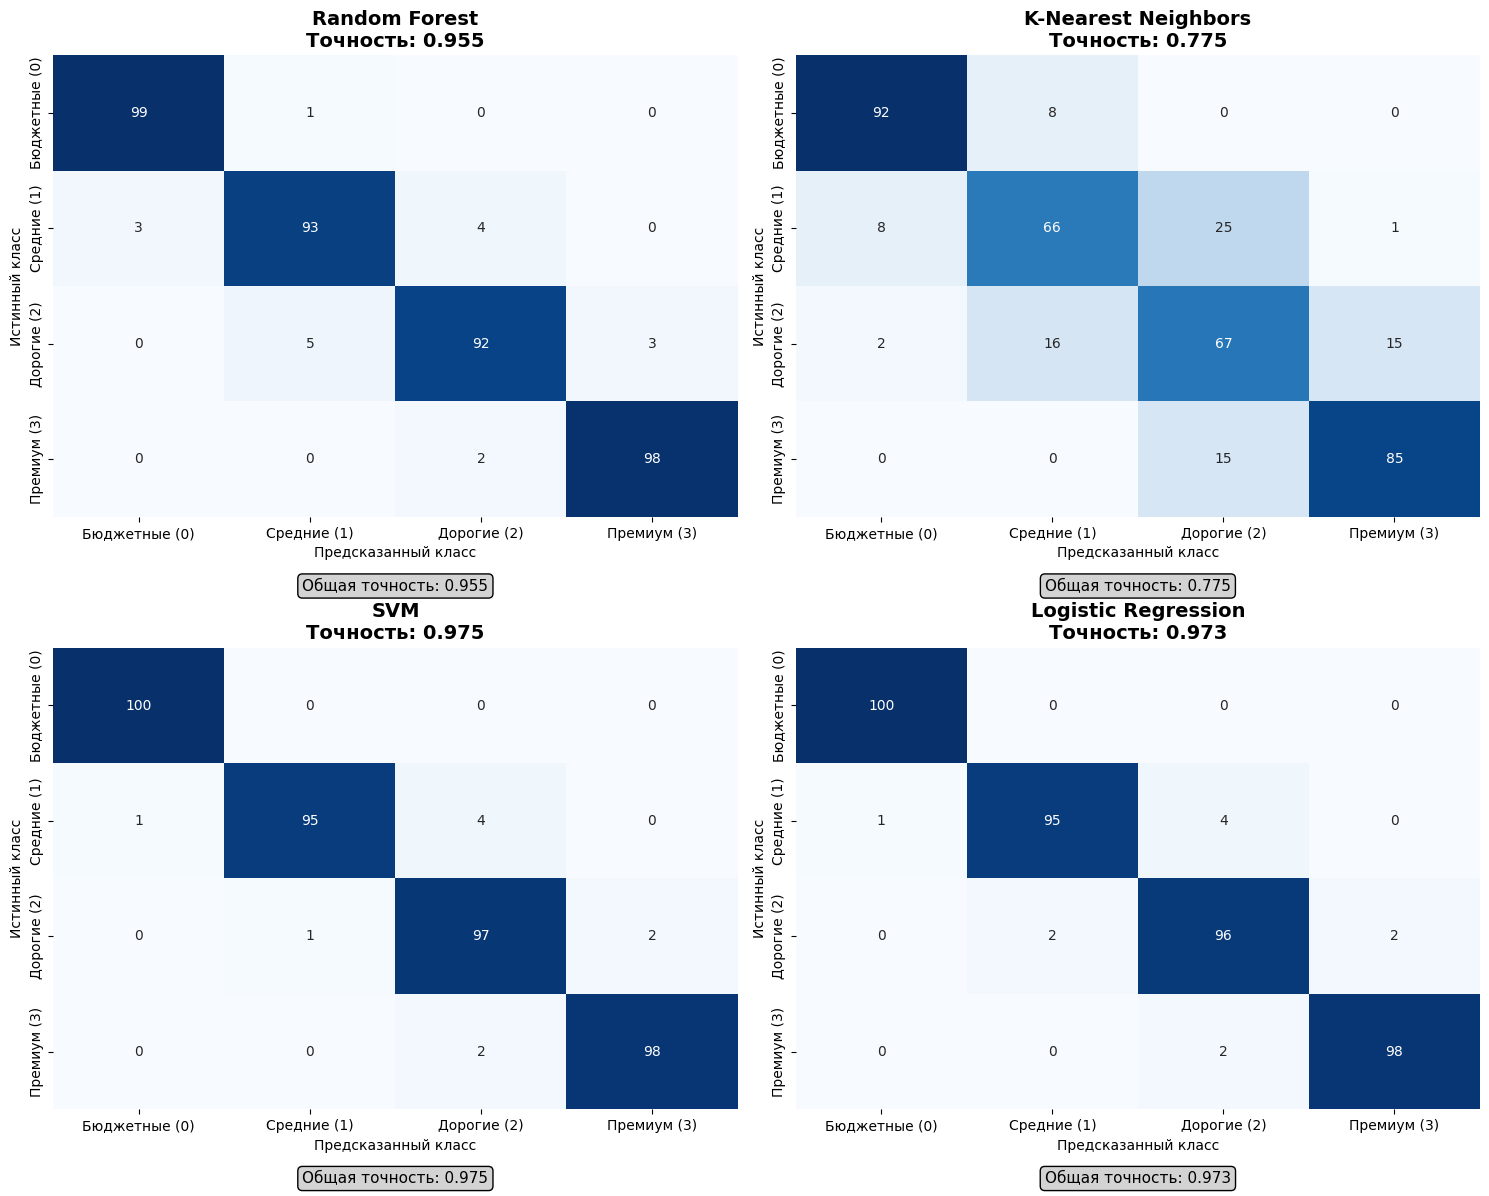

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

class_names = ['Бюджетные (0)', 'Средние (1)', 'Дорогие (2)', 'Премиум (3)']

for idx, (model_name, (y_pred, accuracy)) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
                yticklabels=class_names, ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{model_name}\nТочность: {accuracy:.3f}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Предсказанный класс')
    axes[idx].set_ylabel('Истинный класс')
    
    axes[idx].text(0.5, -0.15, f'Общая точность: {accuracy:.3f}', 
                   ha='center', va='center', transform=axes[idx].transAxes, 
                   fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

plt.tight_layout()
plt.show()

##### вывод
##### SVM и Logistic Regression показали практически одинаковые результаты (разница 0,25%)
##### 97.5% точности - это отличный результат для задачи классификации с 4 классами, модель делает всего 10 ошибок на 400 телефонов

##### лучше использовать  Logistic Regression из-за простоты, качество практически одинаковое разница в 0,25% практически незаметна 